### Imports and helper funs like embedding to scimilarity

In [63]:
# pip install tqdm if you don't already have it
from pathlib import Path
import os, gc, numpy as np, scipy.sparse as sp, torch
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
from scimilarity.cell_annotation import CellAnnotation
from scimilarity.utils import align_dataset, lognorm_counts
from sklearn.metrics import accuracy_score, classification_report
import json
import scanpy as sc
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Apple-GPU flags
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"]      = "0"
# os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0"


In [64]:
import platform
import psutil
import os

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("RAM available:", psutil.virtual_memory().available / 1e9, "GB")
print("PID:", os.getpid())

import numpy as np
big_array = np.empty((1000000, 1000), dtype=np.float32)


Python: 3.11.8
Platform: macOS-15.3.1-arm64-arm-64bit
RAM available: 34.231631872 GB
PID: 57319


In [65]:
# Set up parameters
MODEL_DIR   = Path("/Users/kylekimler/Projects/flagship/scimilarity/data/model_v1.1")
H5AD_PATH   = Path("/Users/kylekimler/Projects/GCA/meta_datasets/20250717_CxG_upload_checkpoint.h5ad")
TEST_SIZE   = 0.20
RAND_SEED   = 42
BATCH = 32  # lower if kernel still crashes 

In [66]:
# DEVICE, DTYPE = "mps", torch.float32          # fp32 everywhere
# enc_base      = encoder.encoder.eval().to(DEVICE)   # freeze decoder away
# for p in enc_base.parameters():               # safety
#     p.requires_grad_(False)


In [67]:
data

AnnData object with n_obs × n_vars = 1497230 × 28231
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platfor

## Load and prepare data

### Set up the scimilarity model

In [68]:

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


ca = CellAnnotation(model_path=str(MODEL_DIR))



### GCA data

In [69]:
# Data loading and preprocessing
data = sc.read_h5ad(H5AD_PATH)

if "gene_symbol" in data.var.columns:
    data.var.set_index("gene_symbol", inplace=True)

if data.var.index.has_duplicates:
    dup_mask = data.var.index.duplicated(keep="first")
    print(f"[warn] Dropping {dup_mask.sum()} duplicated gene symbols.")
    data = data[:, ~dup_mask].copy()

# Align and preprocess exactly as in scimilarity pipeline
data = align_dataset(data, ca.gene_order)




[warn] Dropping 10 duplicated gene symbols.


In [70]:
embeddings = ca.get_embeddings(data.X)

In [71]:
data.obs.columns

Index(['sample_id', 'author_cell_type', 'donor_id', 'dataset_id',
       'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text',
       'sample_source', 'sample_collection_method', 'tissue_type',
       'sampled_site_condition', 'disease_ontology_term',
       'disease_ontology_term_id', 'sample_preservation_method',
       'suspension_type', 'is_primary_data', 'age_range',
       'development_stage_ontology_term_id', 'radial_tissue_term',
       'dissociation_protocol', 'cell_enrichment', 'sample_collection_year',
       'library_id', 'library_id_repository', 'library_preparation_batch',
       'library_sequencing_run', 'sample_collection_site',
       'sample_collection_relative_time_point', 'cell_number_loaded',
       'cell_viability_percentage', 'institute', 'author_batch_notes',
       'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term',
       'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi',
       'contact_email', 'batch_condition

In [74]:
import obonet
import requests
from io import StringIO
import pandas as pd

# Load GCA celltype taxonomy
taxonomy = pd.read_csv("/Users/kylekimler/Projects/GCA/ontology/gca_celltype_taxonomy.csv")

# add CL term for harmonized author celltype to anndata
celltype_to_ontology = taxonomy.set_index("closest_GCA_celltype")["cell_type_ontology_term_id"].dropna()
data.obs["closest_GCA_ontology_term"] = data.obs["closest_GCA_celltype"].map(celltype_to_ontology)


# Download the latest CL ontology (only once needed)
url = 'http://purl.obolibrary.org/obo/cl/cl-basic.obo'
response = requests.get(url)
graph = obonet.read_obo(StringIO(response.text))

# Make a mapping from CL ID to name
cl_to_name = {
    node_id: data.get('name')
    for node_id, data in graph.nodes(data=True)
    if node_id.startswith('CL:')
}

# This is directly from author cell types
data.obs['groundtruth_ontology_labels'] = data.obs['cell_type_ontology_term_id'].map(cl_to_name)

data.obs['harmonized_author_ontology_labels'] = data.obs['closest_GCA_ontology_term'].map(cl_to_name)

taxonomy['harmonized_author_ontology_labels'] = taxonomy['cell_type_ontology_term_id'].map(cl_to_name)


In [31]:
print(*data.obs['cell_type_atlas'].unique())

CD4 T Cells CD8 T Cells ILC1 M1 Memory B Cells Naive B Cells NK Cells Plasma Cells cDC2 ILC3 Germinal Center B Cells (GC) Unconventional T Cells Follicular Dendritic Cells Fibroblasts Submucosal  (S3) Mast Cells Enteroendocrine Cells (EEC) Epithelial Stem Cells (LGR5+) Enterocytes Endothelial Pericytes Colonocytes Fibroblasts Subepithelial (S2) Tuft Cells Paneth Cells Fibroblasts Subserosal Fibroblasts Lamina propria (S1) Glia Myofibroblasts Goblet Cells Transiently Amplifying Cells (TA) Mature goblet cells Fibroblastic reticular cells


## Test the accuracy of the full scimilarity model against ground truths

### Accuracy vs. integrated cell cluster labels (CAP)

In [10]:
LABEL_KEY   = "cell_type_atlas"

labels = data.obs[LABEL_KEY].astype(str).values

# Full model predictions
pred_full, _, _, _ = ca.get_predictions_knn(embeddings, weighting=True)
print("\nFull-model accuracy predicting CAP labels:", accuracy_score(labels, pred_full))
print(classification_report(labels, pred_full, digits=3))


Get nearest neighbors finished in: 0.8181695024172465 min


100%|███████████████████████████████| 1497230/1497230 [03:07<00:00, 7980.12it/s]



Full-model accuracy predicting CAP labels: 0.0


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

                                                                            precision    recall  f1-score   support

                                                                    B cell      0.000     0.000     0.000       0.0
                                          CD14-low, CD16-positive monocyte      0.000     0.000     0.000       0.0
                                                    CD14-positive monocyte      0.000     0.000     0.000       0.0
                                     CD14-positive, CD16-positive monocyte      0.000     0.000     0.000       0.0
                     CD16-negative, CD56-bright natural killer cell, human      0.000     0.000     0.000       0.0
                        CD16-positive, CD56-dim natural killer cell, human      0.000     0.000     0.000       0.0
                                      CD1c-positive myeloid dendritic cell      0.000     0.000     0.000       0.0
                                                               CD4 T Ce

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Accuracy vs. author cell type ontology labels

In [18]:
LABEL_KEY   = "groundtruth_ontology_labels" 

labels = data.obs[LABEL_KEY].astype(str).values

# Full model predictions
pred_full, _, _, _ = ca.get_predictions_knn(embeddings, weighting=True)
print("\nFull-model accuracy predicting author CL labels:", accuracy_score(labels, pred_full))
print(classification_report(labels, pred_full, digits=3))


Get nearest neighbors finished in: 0.7162335634231567 min


100%|███████████████████████████████| 1497230/1497230 [02:55<00:00, 8543.27it/s]



Full-model accuracy predicting author CL labels: 0.2005536891459562


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

                                                                            precision    recall  f1-score   support

                                                                    B cell      0.000     0.000     0.000         0
                                             CD11b-positive dendritic cell      0.000     0.000     0.000     22519
                                          CD14-low, CD16-positive monocyte      0.000     0.000     0.000         0
                                                    CD14-positive monocyte      0.000     0.000     0.000         0
                                     CD14-positive, CD16-positive monocyte      0.000     0.000     0.000         0
                     CD16-negative, CD56-bright natural killer cell, human      0.000     0.000     0.000         0
                        CD16-positive, CD56-dim natural killer cell, human      0.000     0.000     0.000         0
                                      CD1c-positive myeloid dendritic c

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Test the accuracy of the model when white-listing gut cell type labels we have in our taxonomy

In [11]:
LABEL_KEY   = "groundtruth_ontology_labels" 

labels = data.obs[LABEL_KEY].astype(str).values

target_celltypes = taxonomy['harmonized_author_ontology_labels'].astype(str).values

ca.safelist_celltypes(target_celltypes)


In [12]:

# Full model predictions
pred_full, _, _, _ = ca.get_predictions_knn(embeddings, weighting=True)
print("\nFull-model accuracy predicting author CL labels:", accuracy_score(labels, pred_full))
print(classification_report(labels, pred_full, digits=3))


Get nearest neighbors finished in: 3.276354451974233 min


100%|███████████████████████████████| 1497230/1497230 [03:09<00:00, 7920.46it/s]



Full-model accuracy predicting author CL labels: 0.22483185616104406


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

                                                                            precision    recall  f1-score   support

                                                                    B cell      0.000     0.000     0.000         0
                                             CD11b-positive dendritic cell      0.000     0.000     0.000     22519
                                           CD4-positive, alpha-beta T cell      0.863     0.187     0.308    235147
                                    CD4-positive, alpha-beta memory T cell      0.000     0.000     0.000         0
                                           CD8-positive, alpha-beta T cell      0.685     0.092     0.162    225166
                                    CD8-positive, alpha-beta memory T cell      0.000     0.000     0.000         0
                                                                      ILC1      0.000     0.000     0.000     19932
                                                           IgA plasma c

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
ordered_celltypes = taxonomy["harmonized_author_ontology_labels"].dropna().unique().tolist()

used_celltypes = set(labels) | set(pred_full)
filtered_celltypes = [ct for ct in ordered_celltypes if ct in used_celltypes]

cm = confusion_matrix(labels, pred_full, labels=filtered_celltypes)
cm_percent = cm.astype(np.float32)
cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_25303/294444552.py:8: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100


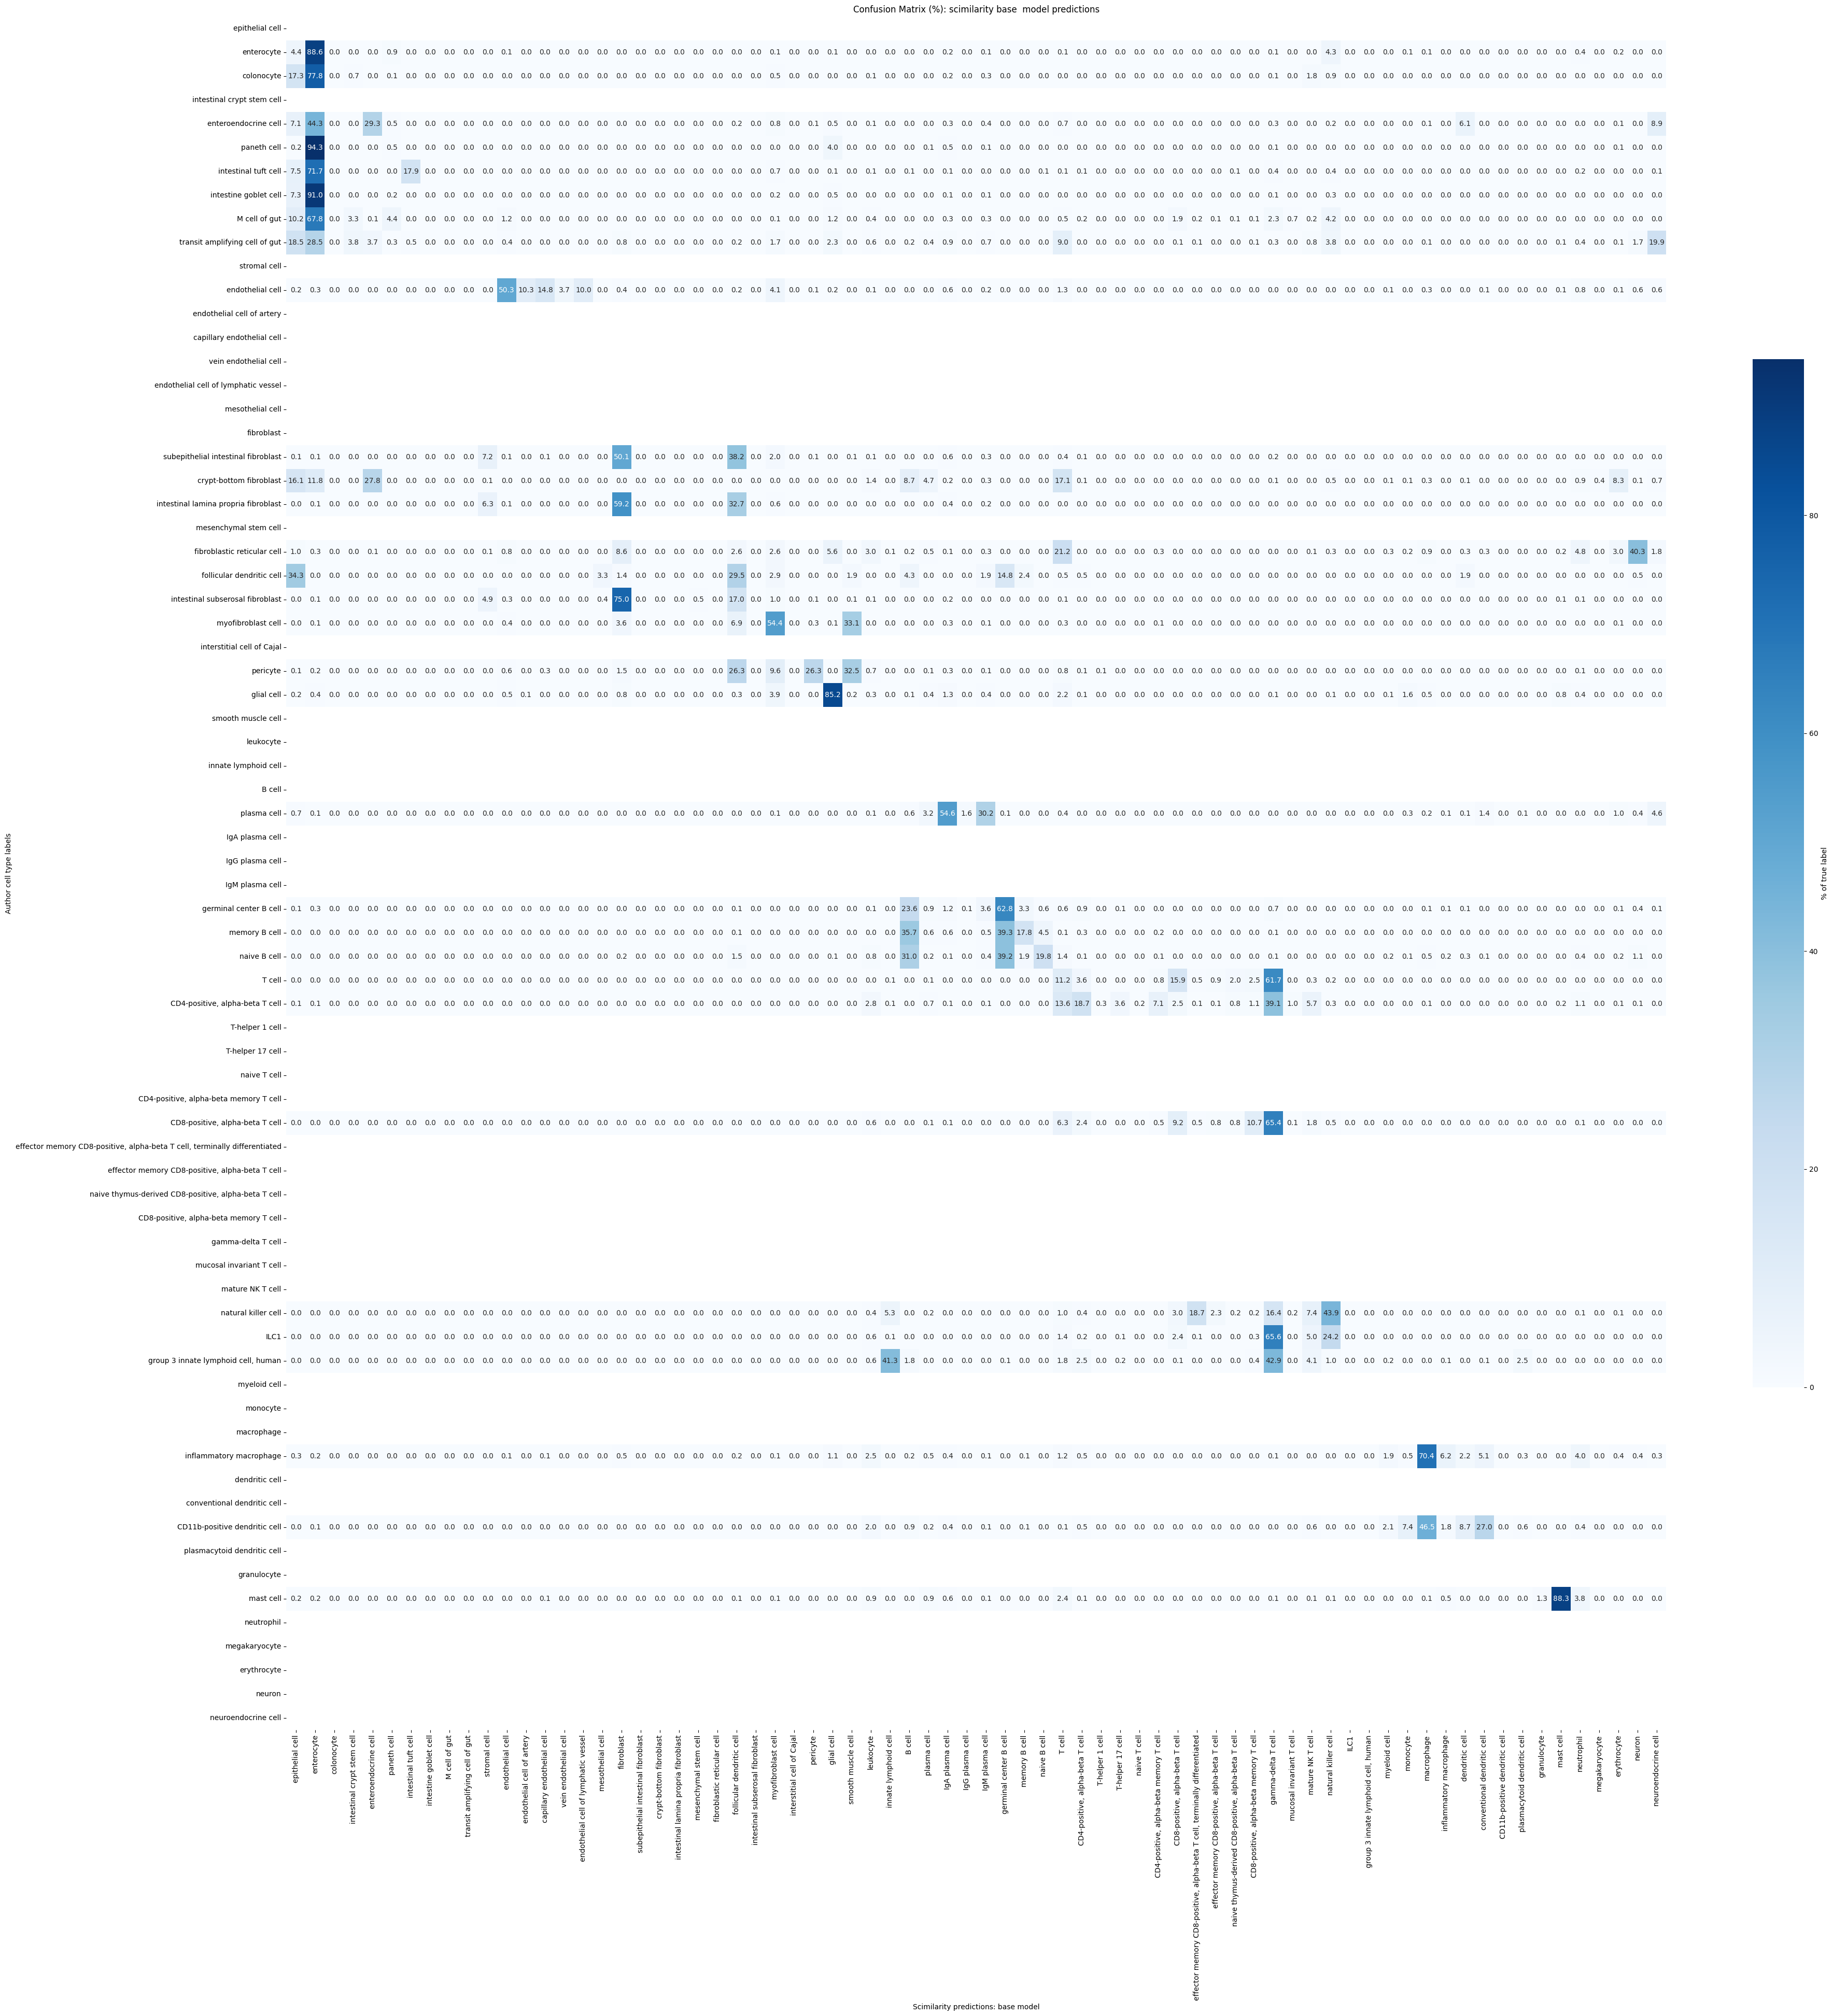

In [14]:
plt.figure(figsize=(len(filtered_celltypes) * 0.5 + 3, len(filtered_celltypes) * 0.5 + 3))
sns.heatmap(cm_percent, annot=True, fmt=".1f",
            xticklabels=filtered_celltypes, 
            yticklabels=filtered_celltypes,
            cmap="Blues", cbar_kws={"label": "% of true label", "shrink": 0.6})
plt.xlabel("Scimilarity predictions: base model")
plt.ylabel("Author cell type labels")
plt.title("Confusion Matrix (%): scimilarity base  model predictions")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Plot taxonomy confusion matrix with taxonomy clade grouping

In [42]:
import pandas as pd

class TreeNode:
    def __init__(self, name):
        self.name = name
        self.children = {}
        self.metadata = {}

    def add_child(self, node_name):
        if node_name not in self.children:
            self.children[node_name] = TreeNode(node_name)
        return self.children[node_name]

def build_tree_from_taxonomy(
    csv_path: str,
    resolution_cols: list[str],
    annotation_cols: list[str] | None = None
) -> TreeNode:
    df = pd.read_csv(csv_path, dtype=str).fillna("")
    df['harmonized_author_ontology_labels'] = (
        df['cell_type_ontology_term_id']
          .map(cl_to_name)
          .fillna(df['cell_type_ontology_term_id'])
    )
    if annotation_cols is None:
        annotation_cols = [c for c in df.columns if c not in resolution_cols]
    root = TreeNode("root")
    for _, row in df.iterrows():
        node = root
        for col in resolution_cols:
            val = row[col]
            if not val:
                break
            node = node.add_child(val)
        for col in annotation_cols:
            node.metadata[col] = row[col]
    return root

def flatten(
    node: TreeNode,
    order: list[str] | None = None,
    depths: list[int] | None = None,
    depth: int = 0,
    name_key: str | None = None
) -> tuple[list[str], list[int]]:
    if order is None:
        order, depths = [], []
    # choose metadata name if requested
    label = node.metadata.get(name_key, node.name) if name_key else node.name
    order.append(label)
    depths.append(depth)
    for child in node.children.values():
        flatten(child, order, depths, depth + 1, name_key)
    return order, depths


In [43]:
csv_path = "/Users/kylekimler/Projects/GCA/ontology/gca_celltype_taxonomy.csv"
resolutions = ["Lineage", "Differentia", "Habitus", "Status", "Whim"]
extras = ["markers", "cell_type_ontology_term_id", "harmonized_author_ontology_labels"]
tree = build_tree_from_taxonomy(
    csv_path,
    resolution_cols=resolutions,
    annotation_cols=['harmonized_author_ontology_labels']
)

flat_labels, flat_depths = flatten( 
    tree, 
    name_key="harmonized_author_ontology_labels" 
)



NameError: name 'pred_full' is not defined

In [41]:
ordered_celltypes = taxonomy["harmonized_author_ontology_labels"].dropna().unique().tolist()

used_celltypes = set(labels) | set(pred_full)
filtered_celltypes = [ct for ct in ordered_celltypes if ct in used_celltypes]

cm = confusion_matrix(labels, pred_full, labels=filtered_celltypes)
cm_percent = cm.astype(np.float32)
cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

# Keep only the set of flattened labels in order (this is for viz purposes)
seen      = set()
nodes     = []
depths    = []
for lbl, dep in zip(flat_labels, flat_depths):
    if lbl not in filtered_celltypes:
        continue
    if lbl in seen:
        continue
    seen.add(lbl)
    nodes.append(lbl)
    depths.append(dep)

boundaries = []
for i in range(1, len(depths)):
    if depths[i] <= depths[i-1]:
        boundaries.append(i)
boundaries.append(len(depths))



NameError: name 'filtered_celltypes' is not defined

In [110]:
df_counts = pd.DataFrame(cm, index=filtered_celltypes, columns=filtered_celltypes)

cm_pct = cm.astype(float)
cm_pct /= cm_pct.sum(axis=1, keepdims=True)
cm_pct *= 100
df_cm_pct = pd.DataFrame(cm_pct, index=filtered_celltypes, columns=filtered_celltypes)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_25303/225916198.py:4: RuntimeWarning: invalid value encountered in divide
  cm_pct /= cm_pct.sum(axis=1, keepdims=True)


In [111]:
cm = confusion_matrix(labels, pred_full, labels=nodes)
cm_pct = (cm.astype(float) 
          / cm.sum(axis=1, keepdims=True) 
          * 100)

df_cm = pd.DataFrame(cm_pct, index=nodes, columns=nodes)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_25303/2164050440.py:2: RuntimeWarning: invalid value encountered in divide
  cm_pct = (cm.astype(float)


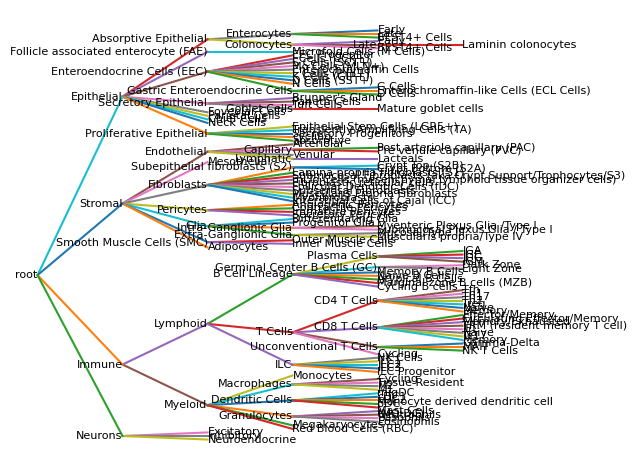

In [51]:
import matplotlib.pyplot as plt

def pretty_print(node, indent=0):
    """Recursively print out node names with indentation."""
    print("  " * indent + node.name)
    for child in node.children.values():
        pretty_print(child, indent + 1)


def plot_tree(node):
    """
    Assign each node an (x,y) based on depth and leaf order,
    then draw lines + labels in matplotlib.
    """
    # 1) Compute positions
    positions = {}
    def _assign(n, depth=0, counter=[0]):
        # if leaf, give it the next y
        if not n.children:
            y = counter[0]
            positions[n] = (depth, y)
            counter[0] += 1
        else:
            # assign positions for children first
            child_ys = []
            for c in n.children.values():
                _assign(c, depth + 1, counter)
                child_ys.append(positions[c][1])
            # place this node midway between its children
            positions[n] = (depth, sum(child_ys) / len(child_ys))
    _assign(node)

    # 2) Plot edges
    fig, ax = plt.subplots()
    for parent, (x1, y1) in positions.items():
        for child in parent.children.values():
            x2, y2 = positions[child]
            ax.plot([x1, x2], [y1, y2])  # default color

    # 3) Plot labels
    for n, (x, y) in positions.items():
        ax.text(x, y, n.name, va="center", ha="right" if n.children else "left",
                fontsize=8)

    ax.invert_yaxis()   # so top of tree is at the top
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_tree(tree)

In [52]:

def plot_heatmaps_by_clade(
    df_cm: pd.DataFrame,
    tree,
    name_key: str,
    clade_level: int,
    ncols: int = 3,
    figsize_per: float = 4,
    fontsize: int = 6
):
    # 1) flatten with full paths
    records = []
    def _recurse(node, depth=0, path=None):
        if path is None: path = []
        label = node.metadata.get(name_key, node.name) if name_key else node.name
        cur_path = path + [label]
        records.append({'label': label, 'depth': depth, 'path': cur_path})
        for child in node.children.values():
            _recurse(child, depth+1, cur_path)
    _recurse(tree)

    df_rec = pd.DataFrame(records)
    # keep only those in the matrix
    df_rec = df_rec[df_rec['label'].isin(df_cm.index)]

    # 2) assign each node to its clade at clade_level
    # clade_level=1 → top‐level (resolution_cols[0]), etc.
    def _clade(path):
        return path[clade_level] if len(path) > clade_level else None
    df_rec['clade'] = df_rec['path'].apply(_clade)

    # 3) plot one heatmap per clade
    clades = [c for c in df_rec['clade'].unique() if c is not None]
    n = len(clades)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols*figsize_per, nrows*figsize_per),
                             squeeze=False)

    for ax, clade in zip(axes.flat, clades):
        labels = df_rec.loc[df_rec['clade']==clade, 'label'].tolist()
        sub = df_cm.loc[labels, labels]
        sns.heatmap(sub, annot=True, fmt=".1f", cmap="Blues",
                    cbar=False, xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_title(f"Clade: {clade}", fontsize=fontsize+2)
        ax.tick_params(axis="x", labelrotation=90, labelsize=fontsize)
        ax.tick_params(axis="y", labelrotation=0, labelsize=fontsize)

    # turn off any unused axes
    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmaps_by_clade_iter(
    df_cm_pct: pd.DataFrame,
    df_counts: pd.DataFrame,
    tree,
    name_key: str,
    clade_level: int,
    fontsize: int = 6,
    size_per_label: float = 0.3,
):
    # 1) Flatten tree into records
    records = []
    def _recurse(n, depth=0, path=None):
        path = (path or []) + [n.metadata.get(name_key, n.name)]
        records.append({'label': path[-1], 'depth': depth, 'path': path})
        for c in n.children.values():
            _recurse(c, depth+1, path)
    _recurse(tree)
    df_rec = pd.DataFrame(records)
    df_rec = df_rec[df_rec['label'].isin(df_cm_pct.index)]
    df_rec['clade'] = df_rec['path'].apply(
        lambda p: p[clade_level] if len(p) > clade_level else None
    )
    clades = [c for c in df_rec['clade'].unique() if c]

    # 2) One full-width plot per clade
    for clade in clades:
        sub_rec = df_rec[df_rec['clade'] == clade]

        # dedupe in tree order
        seen = set()
        labels, depths = [], []
        for _, row in sub_rec.iterrows():
            lbl, dep = row['label'], row['depth']
            if lbl in seen:
                continue
            seen.add(lbl)
            labels.append(lbl)
            depths.append(dep)

        # extract the sub-matrices
        sub_pct    = df_cm_pct.loc[labels, labels].values
        sub_counts = df_counts.loc[labels, labels].values
        n = len(labels)

        # compute clade accuracy = sum(diag) / sum(all true)
        true_pos = np.diag(sub_counts).sum()
        total_true = sub_counts.sum(axis=1).sum()
        acc = true_pos / total_true * 100 if total_true > 0 else 0.0

        # compute internal boundaries for this subset
        boundaries = []
        for i in range(1, n):
            if depths[i] <= depths[i-1]:
                boundaries.append(i)
        boundaries.append(n)

        # mask NaNs so they render blank
        m_sub = np.ma.masked_invalid(sub_pct)
        cmap = plt.cm.Blues.copy()
        cmap.set_bad(color='white')

        fig, ax = plt.subplots(
            figsize=(n * size_per_label + 4, n * size_per_label + 4)
        )
        im = ax.imshow(
            m_sub, interpolation='none', aspect='equal', origin='upper'
        )

        # annotate only real values
        for i in range(n):
            for j in range(n):
                val = sub_pct[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.1f}",
                            ha='center', va='center',
                            fontsize=fontsize)

        # tick labels
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(labels, rotation=90, fontsize=fontsize)
        ax.set_yticklabels(labels, fontsize=fontsize)
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(n - 0.5, -0.5)

        # draw internal-level boundaries
        for b in boundaries:
            ax.axhline(b - 0.5, color='white', lw=1)
            ax.axvline(b - 0.5, color='white', lw=1)

        # colorbar
        cbar = fig.colorbar(im, ax=ax, shrink=0.6)
        cbar.set_label("% of true label", fontsize=fontsize)

        # title with accuracy
        ax.set_title(
            f"Clade: {clade}   (Accuracy: {acc:.1f} %)",
            fontsize=fontsize + 2
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        plt.tight_layout()
        plt.show()

In [69]:
# import math

# plot_heatmaps_by_clade(
#     df_cm,
#     tree,
#     name_key="harmonized_author_ontology_labels",
#     clade_level=1,      # 0=root, 1=Level1, 2=Level2, etc.
#     ncols=2,
#     figsize_per=5,
#     fontsize=8
# )

In [107]:
df_cm.columns

Index(['epithelial cell', 'enterocyte', 'colonocyte',
       'intestinal crypt stem cell', 'enteroendocrine cell', 'paneth cell',
       'intestinal tuft cell', 'intestine goblet cell', 'M cell of gut',
       'transit amplifying cell of gut', 'stromal cell', 'endothelial cell',
       'endothelial cell of artery', 'capillary endothelial cell',
       'vein endothelial cell', 'endothelial cell of lymphatic vessel',
       'mesothelial cell', 'fibroblast', 'subepithelial intestinal fibroblast',
       'crypt-bottom fibroblast', 'intestinal lamina propria fibroblast',
       'mesenchymal stem cell', 'fibroblastic reticular cell',
       'follicular dendritic cell', 'intestinal subserosal fibroblast',
       'myofibroblast cell', 'interstitial cell of Cajal', 'pericyte',
       'glial cell', 'smooth muscle cell', 'leukocyte', 'innate lymphoid cell',
       'B cell', 'plasma cell', 'IgA plasma cell', 'IgG plasma cell',
       'IgM plasma cell', 'germinal center B cell', 'memory B cell',
  

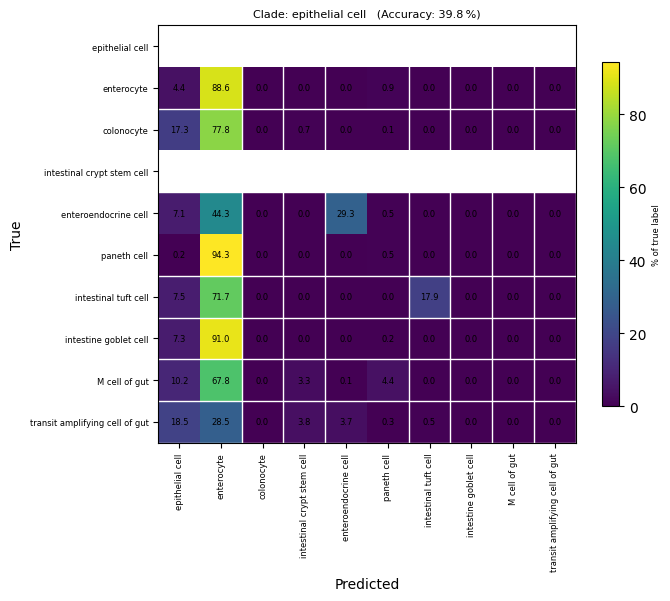

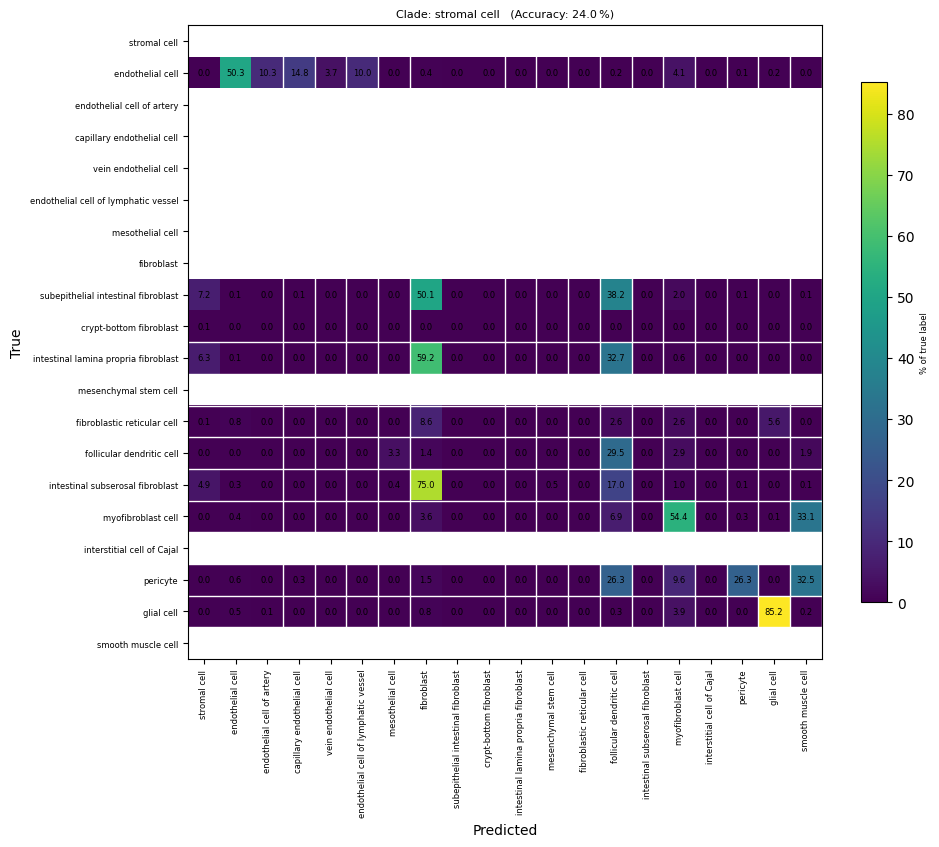

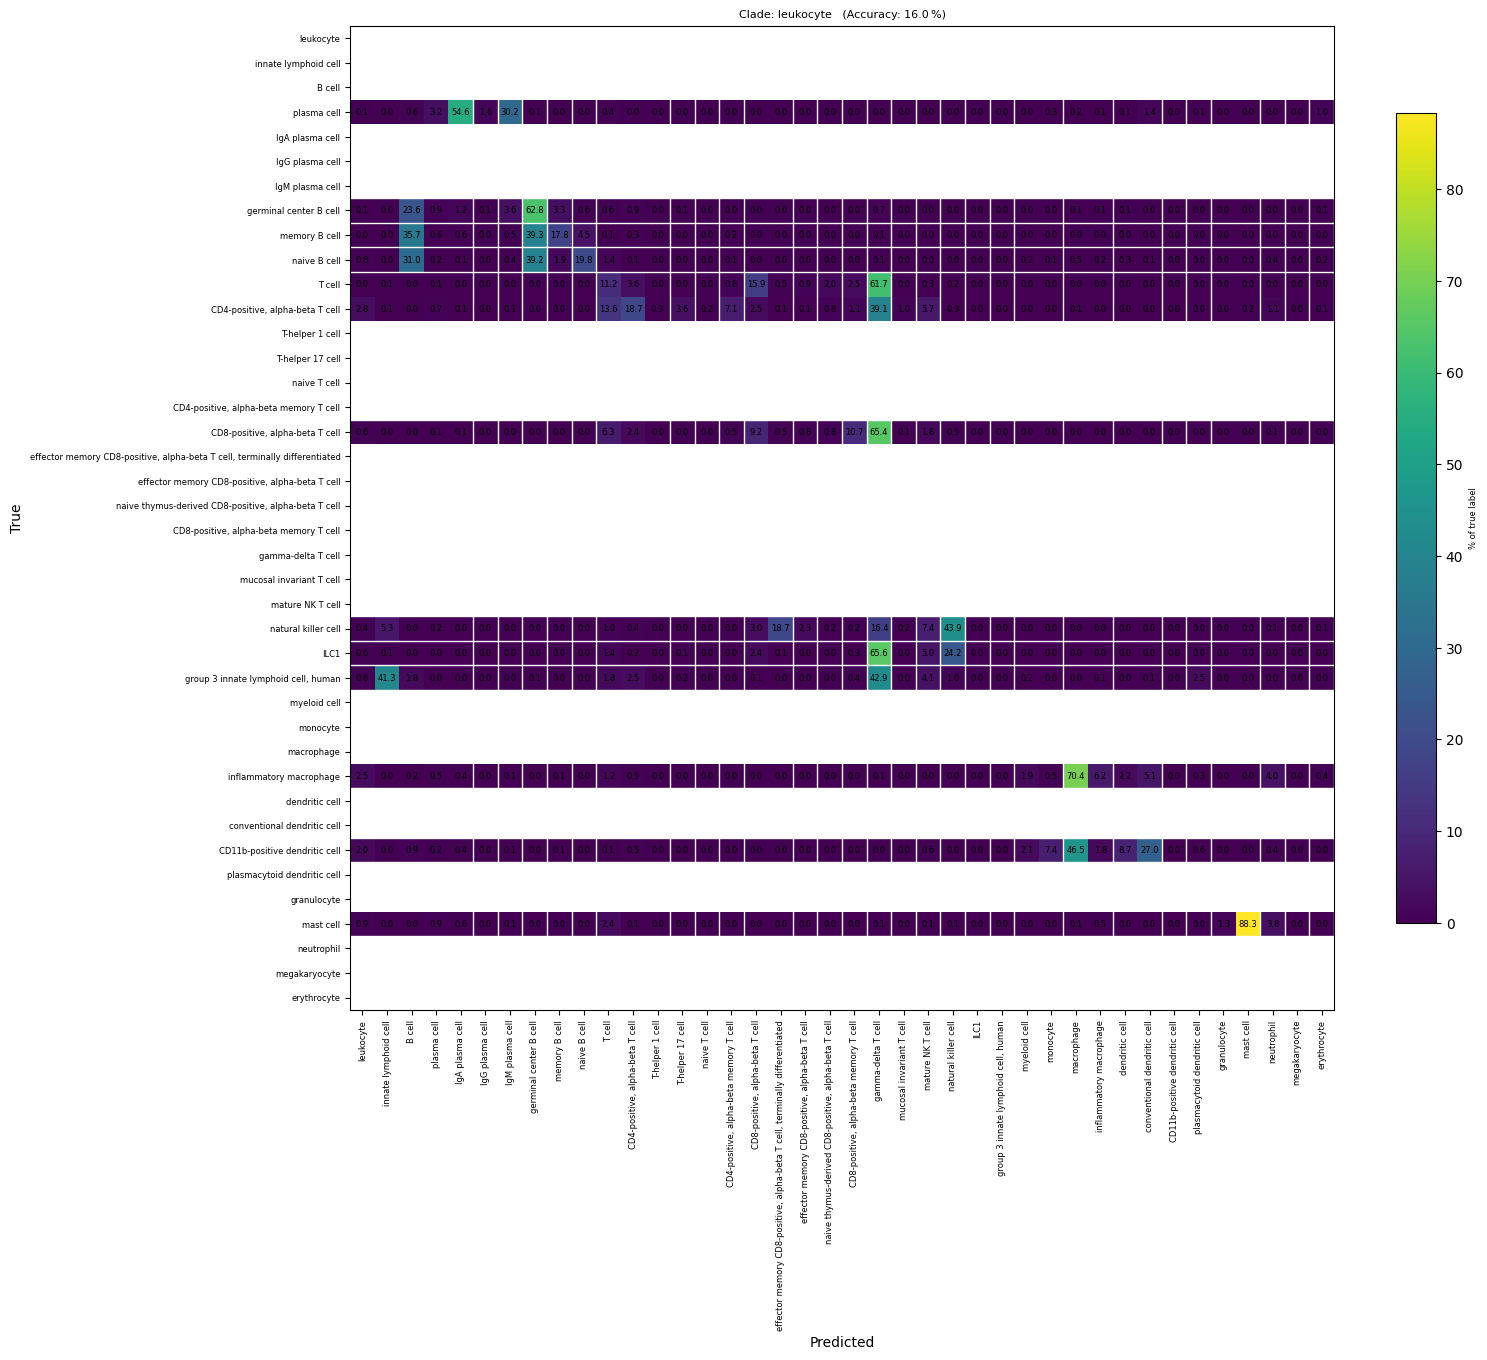

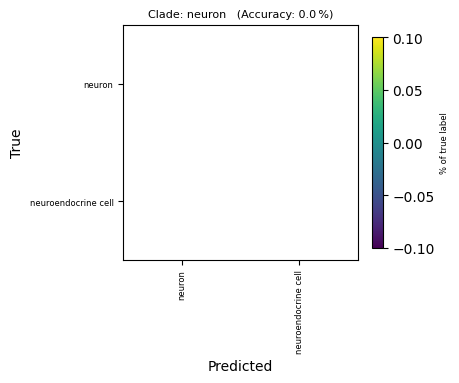

In [115]:
plot_heatmaps_by_clade_iter(
    df_cm_pct,
    df_counts,
    tree,
    name_key="harmonized_author_ontology_labels",
    clade_level=1,
    fontsize=6,
    size_per_label=0.3
)

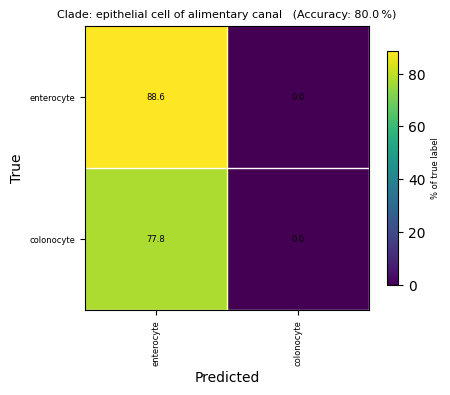

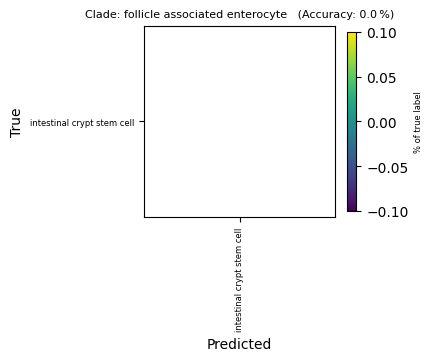

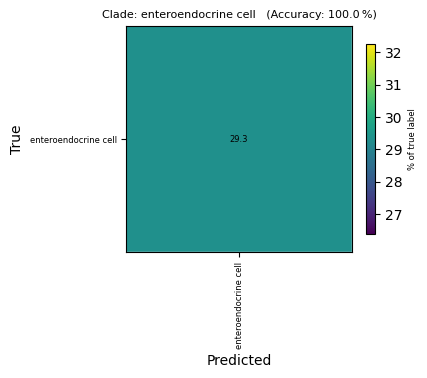

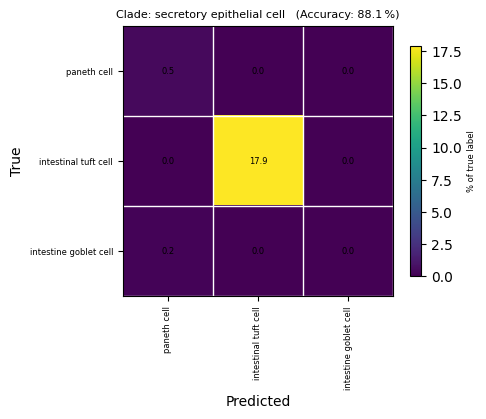

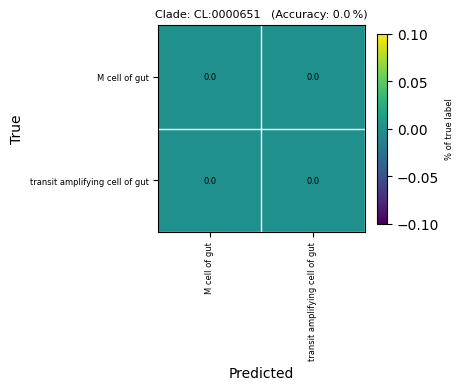

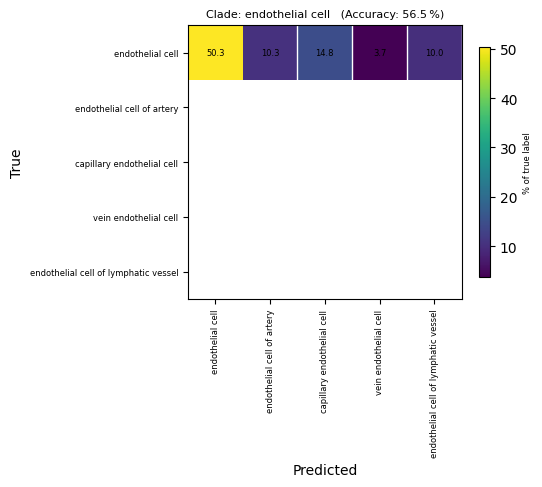

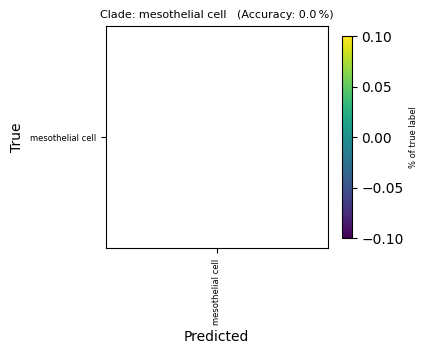

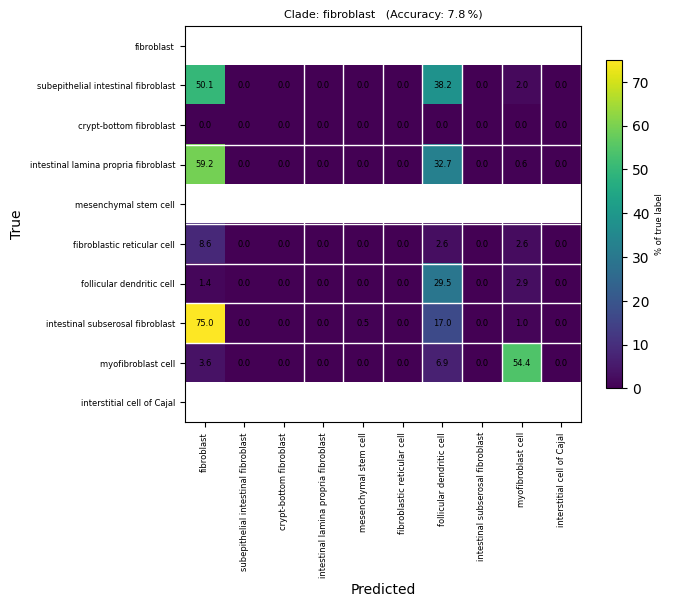

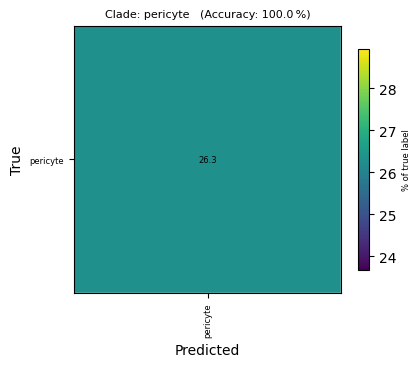

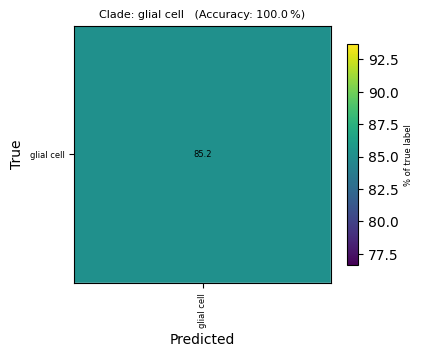

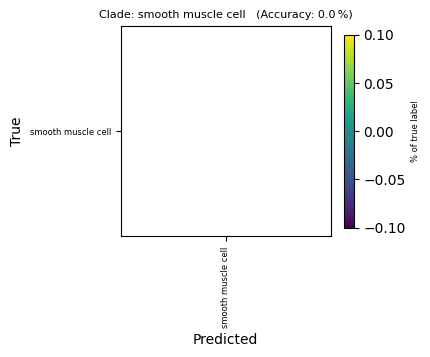

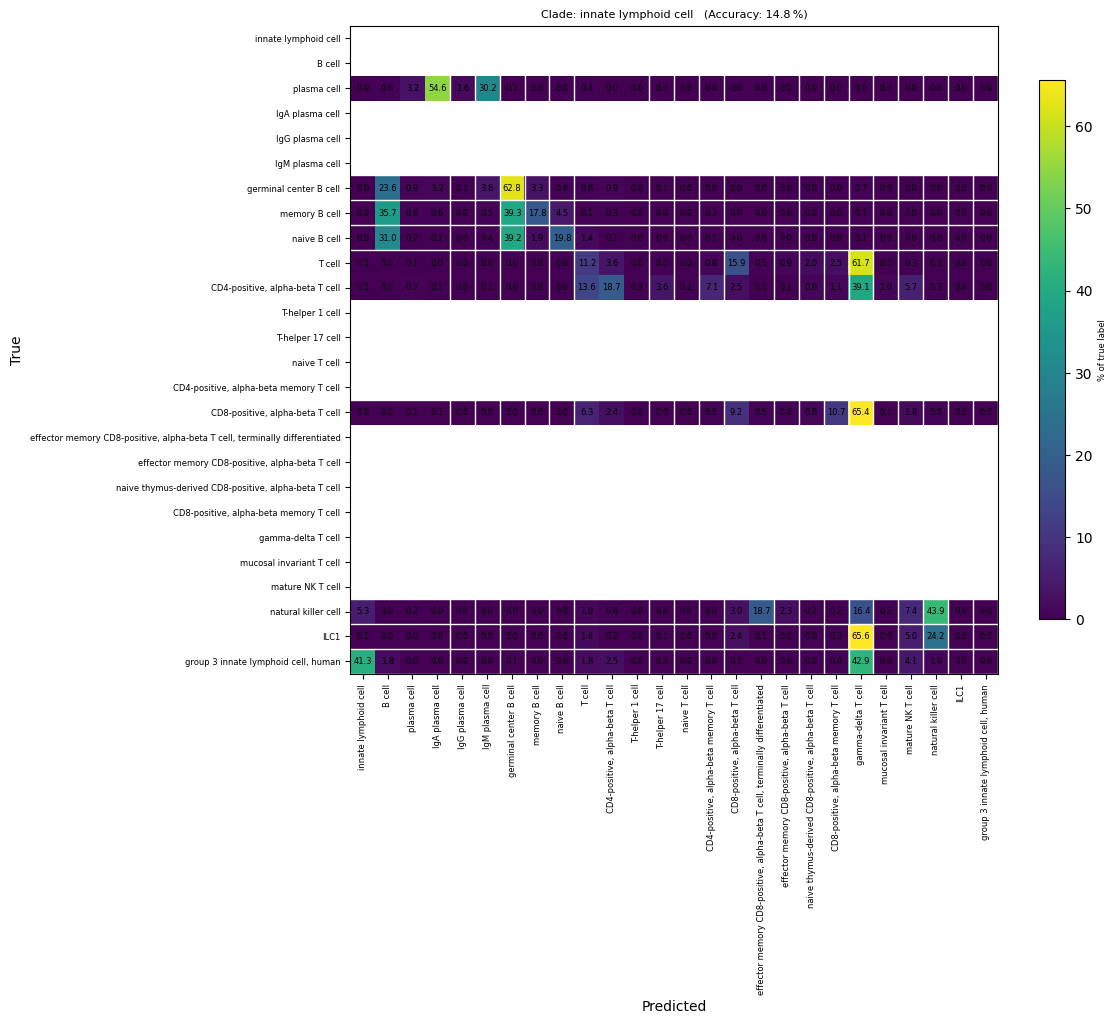

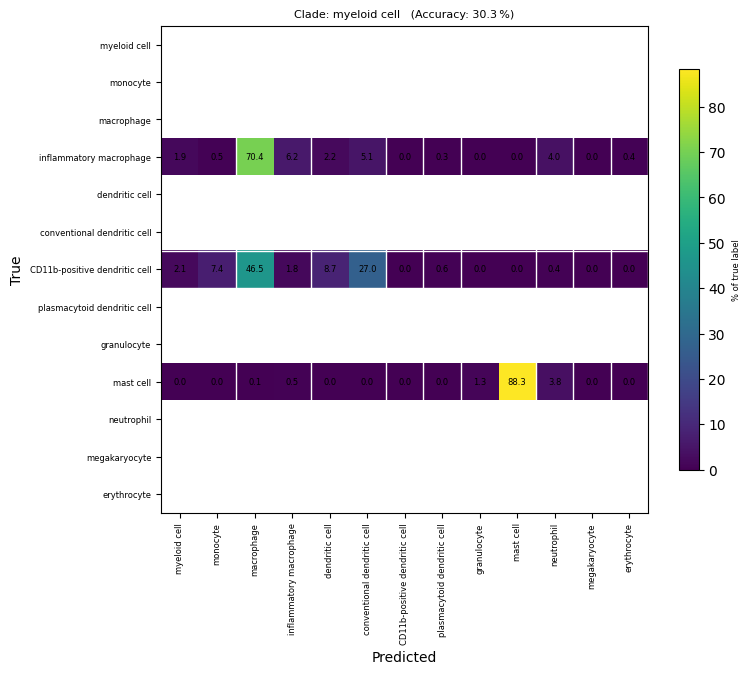

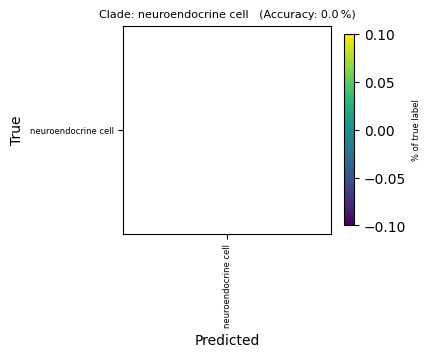

In [116]:
plot_heatmaps_by_clade_iter(
    df_cm_pct,
    df_counts,
    tree,
    name_key="harmonized_author_ontology_labels",
    clade_level=2,
    fontsize=6,
    size_per_label=0.3
)

## Test the full model with safelisted only cell types that are used currently within the taxonomy

In [80]:
LABEL_KEY   = "groundtruth_ontology_labels" 

labels = data.obs[LABEL_KEY].astype(str).values

target_celltypes = np.unique(labels)

ca.safelist_celltypes(labels)

In [81]:

# Full model predictions
pred_full, _, _, _ = ca.get_predictions_knn(embeddings, weighting=True)
print("\nFull-model accuracy predicting author CL labels:", accuracy_score(labels, pred_full))
print(classification_report(labels, pred_full, digits=3))


Get nearest neighbors finished in: 9.593253600597382 min


100%|███████████████████████████████| 1497230/1497230 [02:44<00:00, 9085.81it/s]



Full-model accuracy predicting author CL labels: 0.5349465346005624


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                      precision    recall  f1-score   support

       CD11b-positive dendritic cell      0.000     0.000     0.000     22519
     CD4-positive, alpha-beta T cell      0.895     0.591     0.712    235147
     CD8-positive, alpha-beta T cell      0.867     0.764     0.812    225166
                                ILC1      0.000     0.000     0.000     19932
                       M cell of gut      0.000     0.000     0.000     98736
                              T cell      0.006     0.143     0.011      5481
                          colonocyte      0.000     0.000     0.000     54194
             crypt-bottom fibroblast      0.000     0.000     0.000      7750
                    endothelial cell      0.829     0.902     0.864     26058
                          enterocyte      0.417     0.917     0.573    190809
                enteroendocrine cell      0.177     0.300     0.223      4481
         fibroblastic reticular cell      0.000     0.000     0

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Fine-tune the scimilarity model using GCA celltype labels on a train/test split

In [10]:
from peft import get_peft_model, LoraConfig
import torch
from scimilarity.training_models import MetricLearning

from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [11]:
# Make sure safelists and labels are set up (in case not running full notebook)
LABEL_KEY   = "groundtruth_ontology_labels" 

labels = data.obs[LABEL_KEY].astype(str).values

target_celltypes = taxonomy['harmonized_author_ontology_labels'].astype(str).values

ca.safelist_celltypes(target_celltypes)


In [12]:
# Load pretrained MetricLearning encoder
model = MetricLearning(n_genes=len(ca.gene_order))
encoder_ckpt = torch.load(MODEL_DIR / "encoder.ckpt", map_location="cpu")
encoder_state = {k.replace("encoder.", ""): v for k, v in encoder_ckpt['state_dict'].items() if k.startswith("encoder.")}
model.encoder.load_state_dict(encoder_state, strict=False)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_57319/3165575840.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_ckpt = torch.load(MODEL_DIR / "encode

_IncompatibleKeys(missing_keys=['network.0.1.weight', 'network.0.1.bias', 'network.0.2.weight', 'network.0.2.bias', 'network.0.2.running_mean', 'network.0.2.running_var', 'network.0.3.weight', 'network.1.1.weight', 'network.1.1.bias', 'network.1.2.weight', 'network.1.2.bias', 'network.1.2.running_mean', 'network.1.2.running_var', 'network.1.3.weight', 'network.2.weight', 'network.2.bias'], unexpected_keys=[])

In [13]:
# Configure the LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["network.0.1", "network.1.1", "network.2.1", "network.3"],
    lora_dropout=0.1,
    bias="none",
)

In [14]:
# Integrate LoRA adapters
model.encoder = get_peft_model(model.encoder, lora_config)
model.encoder.print_trainable_parameters()


trainable params: 500,848 || all params: 30,595,314 || trainable%: 1.6370


In [15]:
# Train-test split the anndata. 
idx_train, idx_test = train_test_split(
    np.arange(data.n_obs), test_size=TEST_SIZE, stratify=labels, random_state=RAND_SEED
)

# Prepare data loaders
train_dataset = TensorDataset(torch.tensor(data.X[idx_train].toarray(), dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # using 32 here as we are running locally


In [16]:
# Training setup
optimizer = torch.optim.AdamW(model.encoder.parameters(), lr=1e-4)
n_epochs = 5  # adjust based on needs
model.encoder.train()


PeftModel(
  (base_model): LoraModel(
    (model): Encoder(
      (network): ModuleList(
        (0): Sequential(
          (0): Dropout(p=0.4, inplace=False)
          (1): lora.Linear(
            (base_layer): Linear(in_features=28231, out_features=1024, bias=True)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.1, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=28231, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=1024, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): PReLU(num_parameters=1)
        )
        (1): Sequential(
          (0): Dropout(p=0.5, inplace=

In [17]:
# Precompute reference embeddings for loss supervision

reference_embeddings = torch.tensor(embeddings[idx_train], dtype=torch.float32)


In [18]:
# Fine-tuning loop
for epoch in range(n_epochs):
    total_loss = 0
    batch_start = 0
    for batch in train_loader:
        x_batch = batch[0]
        optimizer.zero_grad()
        embeddings_batch = model.encoder(x_batch)
        target_batch = reference_embeddings[batch_start : batch_start + x_batch.shape[0]].to(x_batch.device)
        loss = F.mse_loss(embeddings_batch, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        batch_start += x_batch.shape[0]
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/5, Loss: 0.0079
Epoch 2/5, Loss: 0.0076
Epoch 3/5, Loss: 0.0075
Epoch 4/5, Loss: 0.0075
Epoch 5/5, Loss: 0.0074


In [19]:
# Eval!
model.encoder.eval()


PeftModel(
  (base_model): LoraModel(
    (model): Encoder(
      (network): ModuleList(
        (0): Sequential(
          (0): Dropout(p=0.4, inplace=False)
          (1): lora.Linear(
            (base_layer): Linear(in_features=28231, out_features=1024, bias=True)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.1, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=28231, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=1024, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): PReLU(num_parameters=1)
        )
        (1): Sequential(
          (0): Dropout(p=0.5, inplace=

In [20]:
# baby batch lora embeddings

@torch.no_grad()
def embed_lora(model, X_csr, batch_size=256):
    out = []
    for i in range(0, X_csr.shape[0], batch_size):
        xb = X_csr[i:i+batch_size].toarray()
        xb = torch.tensor(xb, dtype=torch.float32, device=next(model.encoder.parameters()).device)
        out.append(model.encoder(xb).cpu())
    return torch.cat(out).numpy()

lora_embeddings = embed_lora(model, data.X.tocsr())

In [23]:
from scipy.spatial.distance import cdist

def weighted_cosine_knn(query, ref, ref_labels, k=50, unknown_threshold=0.5, batch_size=250):
    """Memory‑safe cosine distance‑weighted k‑NN with optional "unknown".

    Processes *query* in mini‑batches so we never materialise a full Q×R matrix.
    """
    from scipy.spatial.distance import cdist
    preds = []
    n_query = query.shape[0]
    for start in range(0, n_query, batch_size):
        stop = min(start + batch_size, n_query)
        q_batch = query[start:stop]
        dists   = cdist(q_batch, ref, metric="cosine")         # (B, R)
        nn_idx  = np.argpartition(dists, k - 1, axis=1)[:, :k]  # (B, k)
        for row_d, inds in zip(dists[np.arange(nn_idx.shape[0])[:, None], nn_idx], nn_idx):
            sims  = np.maximum(1.0 - row_d, 0.0)
            w     = sims / sims.sum()
            labs  = ref_labels[inds]
            unique, inv = np.unique(labs, return_inverse=True)
            w_sums = np.zeros(len(unique), dtype=np.float64)
            np.add.at(w_sums, inv, w)
            best = w_sums.argmax()
            top_label, top_weight = unique[best], w_sums[best]
            if unknown_threshold is not None and top_weight < unknown_threshold:
                preds.append("unknown")
            else:
                preds.append(top_label)
    return np.array(preds)



In [24]:
# LoRA evaluation with exact vote rule

pred_lora = weighted_cosine_knn(
    lora_embeddings[idx_test],
    lora_embeddings[idx_train],
    labels[idx_train],
    k=50,
    unknown_threshold=0.5,
)

In [25]:
print("LoRA fine-tuned accuracy:", accuracy_score(labels[idx_test], pred_lora))
print(classification_report(labels[idx_test], pred_lora, digits=3))


LoRA fine-tuned accuracy: 0.39956452916385593


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

                                      precision    recall  f1-score   support

       CD11b-positive dendritic cell      0.357     0.001     0.002      4504
     CD4-positive, alpha-beta T cell      0.655     0.309     0.420     47029
     CD8-positive, alpha-beta T cell      0.663     0.472     0.552     45033
                                ILC1      0.000     0.000     0.000      3986
                       M cell of gut      0.747     0.646     0.693     19747
                              T cell      0.000     0.000     0.000      1096
                          colonocyte      0.658     0.304     0.416     10839
             crypt-bottom fibroblast      0.930     0.700     0.799      1550
                    endothelial cell      0.000     0.000     0.000      5212
                          enterocyte      0.732     0.593     0.655     38162
                enteroendocrine cell      0.000     0.000     0.000       896
         fibroblastic reticular cell      1.000     0.001     0

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
print(classification_report(labels[idx_test], pred_lora, digits=3))


/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

                                      precision    recall  f1-score   support

       CD11b-positive dendritic cell      0.357     0.001     0.002      4504
     CD4-positive, alpha-beta T cell      0.655     0.309     0.420     47029
     CD8-positive, alpha-beta T cell      0.663     0.472     0.552     45033
                                ILC1      0.000     0.000     0.000      3986
                       M cell of gut      0.747     0.646     0.693     19747
                              T cell      0.000     0.000     0.000      1096
                          colonocyte      0.658     0.304     0.416     10839
             crypt-bottom fibroblast      0.930     0.700     0.799      1550
                    endothelial cell      0.000     0.000     0.000      5212
                          enterocyte      0.732     0.593     0.655     38162
                enteroendocrine cell      0.000     0.000     0.000       896
         fibroblastic reticular cell      1.000     0.001     0

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
ordered_celltypes = taxonomy["harmonized_author_ontology_labels"].dropna().unique().tolist()

used_celltypes = set(labels[idx_test]) | set(pred_lora)
filtered_celltypes = [ct for ct in ordered_celltypes if ct in used_celltypes]

cm = confusion_matrix(labels[idx_test], pred_lora, labels=filtered_celltypes)
cm_percent = cm.astype(np.float32)
cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

# Keep only the set of flattened labels in order (this is for viz purposes)
seen      = set()
nodes     = []
depths    = []
for lbl, dep in zip(flat_labels, flat_depths):
    if lbl not in filtered_celltypes:
        continue
    if lbl in seen:
        continue
    seen.add(lbl)
    nodes.append(lbl)
    depths.append(dep)

boundaries = []
for i in range(1, len(depths)):
    if depths[i] <= depths[i-1]:
        boundaries.append(i)
boundaries.append(len(depths))



In [48]:
cm = confusion_matrix(labels[idx_test], pred_lora, labels=nodes)
cm_pct = (cm.astype(float) 
          / cm.sum(axis=1, keepdims=True) 
          * 100)

df_cm = pd.DataFrame(cm_pct, index=nodes, columns=nodes)


In [54]:
df_counts = pd.DataFrame(cm, index=filtered_celltypes, columns=filtered_celltypes)

cm_pct = cm.astype(float)
cm_pct /= cm_pct.sum(axis=1, keepdims=True)
cm_pct *= 100
df_cm_pct = pd.DataFrame(cm_pct, index=filtered_celltypes, columns=filtered_celltypes)


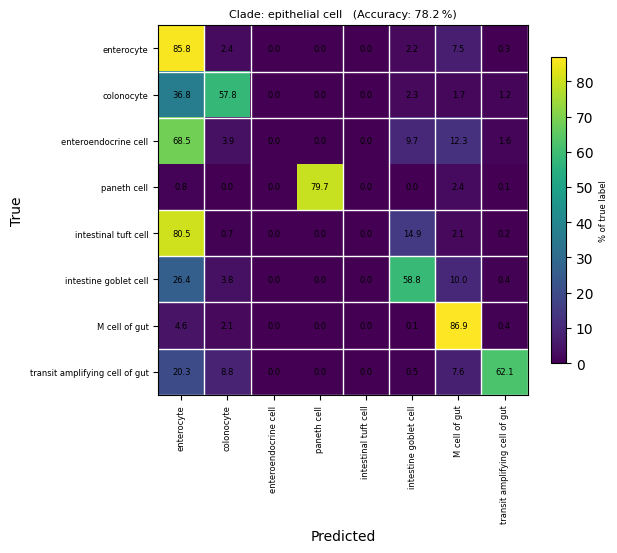

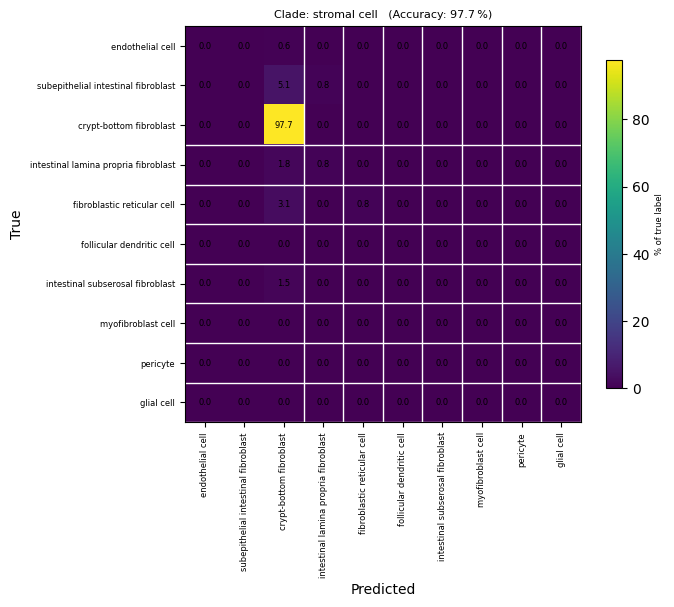

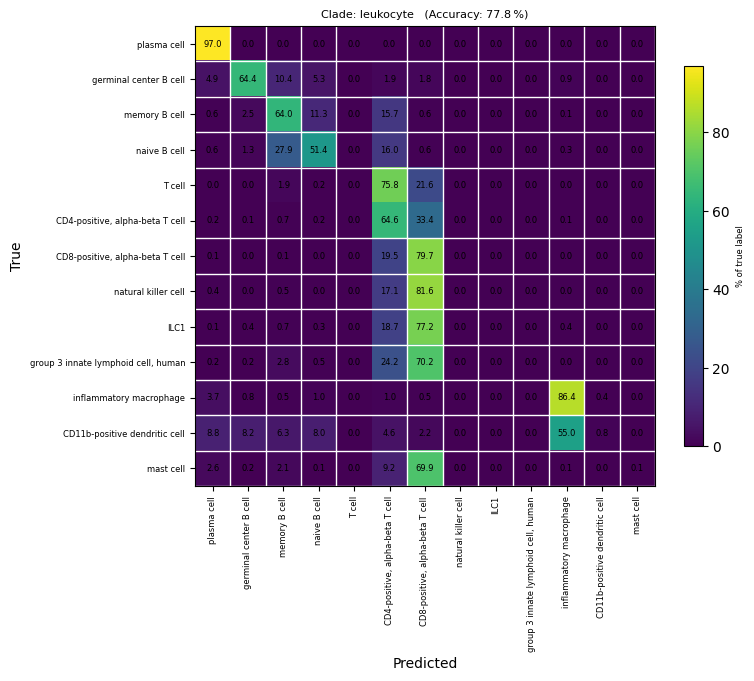

In [55]:
plot_heatmaps_by_clade_iter(
    df_cm_pct,
    df_counts,
    tree,
    name_key="harmonized_author_ontology_labels",
    clade_level=1,
    fontsize=6,
    size_per_label=0.3
)

In [50]:
# # LoRA 5-fold cross val
# This currently uses embeddings directly so it doesn't re-embed which ruins the whole points of CV lol
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RAND_SEED)
# cv_acc_lora = []
# for fold, (tr, te) in enumerate(cv.split(embeddings, labels), 1):
#     pred_fold = weighted_cosine_knn(
#         embeddings[te],
#         embeddings[tr],
#         labels[tr],
#         k=50,
#         unknown_threshold=0.5,
#         batch_size = 2000
#     )
#     acc = accuracy_score(labels[te], pred_fold)
#     cv_acc_lora.append(acc)
#     print(f"Fold {fold}: {acc:.4f}")
# print(f"\nLoRA 5-fold CV accuracy: {np.mean(cv_acc_lora):.4f} ± {np.std(cv_acc_lora):.4f}")


## scArches test/train

In [1]:
from scvi.model import SCVI


In [2]:
# Setup scVI model
adata_scar = data.copy()
SCVI.setup_anndata(adata_scar, labels_key=LABEL_KEY)

# Train/test split same as earlier
adata_scar.obs["train_test"] = "train"
adata_scar.obs.iloc[idx_test, adata_scar.obs.columns.get_loc("train_test")] = "test"


NameError: name 'data' is not defined

In [ ]:
# Create and train scVI model
scvi_model = SCVI(adata_scar)
scvi_model.train(max_epochs=250, plan_kwargs={"lr": 1e-3})

# Extract latent space from scVI
adata_scar.obsm["X_scar"] = scvi_model.get_latents()


In [ ]:
# Evaluate embeddings with same kNN + accuracy framework
from scimilarity.utils import knn_predict_weighted_cosine

Z_scar = adata_scar.obsm["X_scar"]
pred_scar, _, _, _ = knn_predict_weighted_cosine(
    Z_scar[idx_test], reference_embeddings=Z_scar[idx_train], reference_labels=labels[idx_train], k=50
)


In [ ]:
print("scArches baseline accuracy:", accuracy_score(labels[idx_test], pred_scar))
print(classification_report(labels[idx_test], pred_scar, digits=3))


## Leftover code

In [15]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "mps" else torch.float32
print(f"Embedding on {DEVICE} (dtype={DTYPE})…")

# Ensure deterministic splitting
rng = np.random.default_rng(RAND_SEED)
os.environ["PYTHONHASHSEED"] = str(RAND_SEED)


CPU times: user 55.3 s, sys: 50.1 s, total: 1min 45s
Wall time: 2min 12s


In [17]:
adata

View of AnnData object with n_obs × n_vars = 1497230 × 28231
    obs: 'sample_id', 'author_cell_type', 'closest_GCA_celltype_x', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'defau

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_3684/3136054070.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['groundtruth_ontology_labels'] = adata.obs['cell_type_ontology_term_id'].map(cl_to_name)


In [25]:
adata.obs['groundtruth_ontology_labels'].value_counts()

groundtruth_ontology_labels
CD4-positive, alpha-beta T cell         235147
CD8-positive, alpha-beta T cell         225166
enterocyte                              190809
plasma cell                             156269
M cell of gut                            98736
intestine goblet cell                    76897
memory B cell                            64393
naive B cell                             55555
colonocyte                               54194
inflammatory macrophage                  45133
transit amplifying cell of gut           44992
intestinal lamina propria fibroblast     27542
mast cell                                26945
germinal center B cell                   26660
endothelial cell                         26058
CD11b-positive dendritic cell            22519
ILC1                                     19932
intestinal subserosal fibroblast         14938
natural killer cell                      12479
subepithelial intestinal fibroblast      11024
myofibroblast cell              

### Test/Train split

In [26]:
label_col = "groundtruth_ontology_labels"
labels    = adata.obs[label_col].values
idx_train, idx_test = train_test_split(
        np.arange(adata.n_obs), test_size=0.2, stratify=labels, random_state=0)

csr_train, y_train = adata.X[idx_train], labels[idx_train]
csr_test,  y_test  = adata.X[idx_test] , labels[idx_test]

### embeddings saved to disk - because these chunks are huge

In [42]:
from tqdm.auto import tqdm   # prettier in notebooks

DEVICE, DTYPE = "mps", torch.float32   # fp32 everywhere

def embed_csr_to_disk(csr: sp.csr_matrix, encoder, out_dir: Path, batch=32):
    out_dir.mkdir(parents=True, exist_ok=True)
    enc = encoder.eval().to(DEVICE)
    for p in enc.parameters():
        p.requires_grad = False

    for i in range(0, csr.shape[0], batch):
        dense = csr[i:i+batch].todense().astype(np.float32)
        xb = torch.from_numpy(np.asarray(dense)).to(DEVICE)

        out = enc(xb).cpu().numpy()
        np.save(out_dir / f"embed_{i:06d}.npy", out)

        del xb, out, dense
        torch.mps.synchronize()
        torch.mps.empty_cache()
        gc.collect()

        if i % (batch * 100) == 0:
            print(f"[{i}] Saved batch to disk…")


# from pathlib import Path
# import numpy as np, tqdm, gc

# def concat_chunks_to_memmap(src_dir: Path, out_file: str | Path):
#     files = sorted(src_dir.glob("embed_*.npy"))
#     if not files:
#         raise FileNotFoundError(f"No embed_*.npy files in {src_dir}")

#     # read first & last to know per-chunk shape and final tail
#     first = np.load(files[0], mmap_mode="r")
#     rows_per_chunk, latent_dim = first.shape
#     last_rows = np.load(files[-1], mmap_mode="r").shape[0]
#     total_rows = rows_per_chunk * (len(files) - 1) + last_rows

#     # allocate destination mem-map
#     mm = np.lib.format.open_memmap(
#         out_file, mode="w+", dtype=first.dtype, shape=(total_rows, latent_dim)
#     )

#     # copy chunk → memmap
#     write_idx = 0
#     for f in tqdm.tqdm(files, desc="stitch", unit="file"):
#         chunk = np.load(f, mmap_mode="r")          # memmap; no context-manager
#         r = chunk.shape[0]
#         mm[write_idx : write_idx + r] = chunk
#         write_idx += r
#         del chunk                                  # close file handle quickly
#         gc.collect()

#     mm.flush()
#     print("✓ concatenated memmap:", out_file, "shape:", mm.shape)
#     return np.load(out_file, mmap_mode="r")        # ready for downstream use

from pathlib import Path
import numpy as np, tqdm, gc

def concat_chunks(src_dir, out_path):
    src_dir  = Path(src_dir)
    out_path = Path(out_path)
    files    = sorted(src_dir.glob("embed_*.npy"))
    if not files:
        raise FileNotFoundError(f"No embed_*.npy files in {src_dir}")

    # ── pass 1: scan headers ────────────────────────────────────────────
    total_rows = 0
    latent_dim = None
    dtype      = None
    row_counts = []                     # keep per-file row count
    for f in files:
        arr = np.load(f, mmap_mode="r")
        r, d = arr.shape
        row_counts.append(r)
        total_rows += r
        latent_dim = d if latent_dim is None else latent_dim
        dtype      = arr.dtype if dtype is None else dtype

    print(f"⇢ stitching {len(files)} chunks, rows={total_rows}, dim={latent_dim}")

    # ── create destination mem-map ──────────────────────────────────────
    out_path.parent.mkdir(parents=True, exist_ok=True)
    mm = np.lib.format.open_memmap(out_path, mode="w+",
                                   dtype=dtype, shape=(total_rows, latent_dim))

    # ── pass 2: copy data ───────────────────────────────────────────────
    offset = 0
    for f, r in tqdm.tqdm(zip(files, row_counts), total=len(files),
                          desc="stitch", unit="file"):
        chunk = np.load(f, mmap_mode="r")
        mm[offset : offset + r] = chunk
        offset += r
        del chunk; gc.collect()

    mm.flush()
    print(f"✓ stitched into {out_path}  shape={mm.shape}")
    return np.load(out_path, mmap_mode="r")      # downstream-ready


### Baseline embeddings - we use custom embeddings rather than scimilarity's built-in function to make comparison to LoRA hack easier

In [30]:
%%time
path_train = Path("/Users/kylekimler/Projects/GCA/scimilarity/lora_model_train")
path_test = Path("/Users/kylekimler/Projects/GCA/scimilarity/lora_model_test")

embed_csr_to_disk(csr_train, enc_base, path_train, batch=64)
embed_csr_to_disk(csr_test, enc_base, path_test, batch=64)


[0] Saved batch to disk…
[6400] Saved batch to disk…
[12800] Saved batch to disk…
[19200] Saved batch to disk…
[25600] Saved batch to disk…
[32000] Saved batch to disk…
[38400] Saved batch to disk…
[44800] Saved batch to disk…
[51200] Saved batch to disk…
[57600] Saved batch to disk…
[64000] Saved batch to disk…
[70400] Saved batch to disk…
[76800] Saved batch to disk…
[83200] Saved batch to disk…
[89600] Saved batch to disk…
[96000] Saved batch to disk…
[102400] Saved batch to disk…
[108800] Saved batch to disk…
[115200] Saved batch to disk…
[121600] Saved batch to disk…
[128000] Saved batch to disk…
[134400] Saved batch to disk…
[140800] Saved batch to disk…
[147200] Saved batch to disk…
[153600] Saved batch to disk…
[160000] Saved batch to disk…
[166400] Saved batch to disk…
[172800] Saved batch to disk…
[179200] Saved batch to disk…
[185600] Saved batch to disk…
[192000] Saved batch to disk…
[198400] Saved batch to disk…
[204800] Saved batch to disk…
[211200] Saved batch to disk…
[

In [43]:
train_chunks = "/Users/kylekimler/Projects/GCA/scimilarity/lora_model_train"
test_chunks  = "/Users/kylekimler/Projects/GCA/scimilarity/lora_model_test"

Z_train = concat_chunks(train_chunks, "train_latents.npy")
Z_test  = concat_chunks(test_chunks , "test_latents.npy")

assert Z_train.shape[0] == len(y_train)
assert Z_test.shape[0]  == len(y_test)

⇢ stitching 18716 chunks, rows=1197784, dim=128


stitch: 100%|███████████████████████████| 18716/18716 [57:42<00:00,  5.40file/s]


✓ stitched into train_latents.npy  shape=(1197784, 128)
⇢ stitching 4679 chunks, rows=299446, dim=128


stitch: 100%|█████████████████████████████| 4679/4679 [17:02<00:00,  4.57file/s]


✓ stitched into test_latents.npy  shape=(299446, 128)


In [45]:
%%time
knn = KNeighborsClassifier(n_neighbors=50, metric="cosine",weights="distance").fit(Z_train, y_train)
acc_base = accuracy_score(y_test, knn.predict(Z_test))
print(f"Baseline KNN accuracy: {acc_base:.4f}")


Baseline KNN accuracy: 0.2640
CPU times: user 3h 29min 8s, sys: 38min 46s, total: 4h 7min 54s
Wall time: 2h 2min 52s


In [ ]:

# ───────────────────────────────────────────────────────────────────────────────
# ───────────────────────────────────────────────────────────────────────────────
# Evaluation
#   • 80/20 hold‑out with **weighted cosine k‑NN (k=50)**
#   • 5‑fold stratified CV on the same embeddings
#   • report macro‑averaged precision/recall/F1
# ───────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

# ---- helper: weighted‑vote cosine k‑NN via sklearn ---------------------------
knn_wcos = KNeighborsClassifier(
    n_neighbors=50,
    metric="cosine",
    weights="distance",  # ≈ SCimilarity weighting
    n_jobs=-1,
)

# 1) 80/20 hold‑out ------------------------------------------------------------
knn_wcos.fit(Z[idx_train], labels[idx_train])
ho_pred = knn_wcos.predict(Z[idx_test])
print("📊 80/20 hold‑out accuracy:", accuracy_score(labels[idx_test], ho_pred))
print(classification_report(labels[idx_test], ho_pred, digits=3))

# 2) 5‑fold CV ---------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RAND_SEED)
cv_acc = []
for fold, (tr, te) in enumerate(cv.split(Z, labels), 1):
    knn_wcos.fit(Z[tr], labels[tr])
    cv_pred = knn_wcos.predict(Z[te])
    acc = accuracy_score(labels[te], cv_pred)
    cv_acc.append(acc)
    print(f"fold {fold}: {acc:.4f}")
print(f"
📊 5‑fold CV accuracy: {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")


### Attach LoRA adapters and fine-tune


In [47]:
%pip install peft

  Using cached peft-0.16.0-py3-none-any.whl.metadata (14 kB)
  Using cached transformers-4.53.1-py3-none-any.whl.metadata (40 kB)
  Using cached accelerate-1.8.1-py3-none-any.whl.metadata (19 kB)
Using cached peft-0.16.0-py3-none-any.whl (472 kB)
Using cached accelerate-1.8.1-py3-none-any.whl (365 kB)
Using cached transformers-4.53.1-py3-none-any.whl (10.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F

lora_cfg = LoraConfig(r=8, lora_alpha=32, target_modules=["network.0.1", "network.1.1", "network.2.1", "network.3"],
                      lora_dropout=0.05, bias="none")
enc_lora = get_peft_model(enc_base, lora_cfg)
enc_lora.train()

class CsrDataset(torch.utils.data.Dataset):
    def __init__(self, csr, labels): self.csr, self.labels = csr, labels
    def __len__(self): return self.csr.shape[0]
    def __getitem__(self, i):
        return (torch.as_tensor(self.csr[i].toarray(), dtype=DTYPE),
                self.labels[i])

train_loader = torch.utils.data.DataLoader(
    CsrDataset(csr_train, y_train), batch_size=256, shuffle=True,
    collate_fn=lambda xs: (torch.vstack([x[0] for x in xs]).to(DEVICE),
                           torch.tensor([x[1] for x in xs], device=DEVICE)))

opt = torch.optim.AdamW(enc_lora.parameters(), lr=3e-4)

def supcon_loss(z, y, temp=0.1):
    z = F.normalize(z, dim=1)
    sim = torch.mm(z, z.T) / temp
    mask = (y[:,None] == y[None,:]).float()
    sim = sim - torch.eye(len(y), device=z.device)*1e9
    log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
    return -(mask*log_prob).sum() / mask.sum()

for ep in range(3):
    for xb, yb in tqdm.tqdm(train_loader, desc=f"LoRA epoch {ep+1}", leave=False):
        opt.zero_grad()
        loss = supcon_loss(enc_lora(xb), yb)
        loss.backward(); opt.step()


/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/Applications/minicondaX/miniconda3/envs/decoupler/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:190: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
LoRA epoch 1:   0%|                                    | 0/4679 [00:00<?, ?it/s]

In [ ]:
print(enc_base)

In [51]:
for name, module in enc_base.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(name)

network.0.1
network.1.1
network.2.1
network.3


### freeze LoRA, obtain embeddings & scores

In [ ]:
path_train_l = Path("emb_chunks/lora/train")
path_test_l  = Path("emb_chunks/lora/test")

embed_csr_to_chunks(csr_train, path_train_l, enc_lora, batch=512)
embed_csr_to_chunks(csr_test , path_test_l , enc_lora, batch=512)

Z_train_lora = load_chunks(path_train_l)
Z_test_lora  = load_chunks(path_test_l)

knn_lora = KNeighborsClassifier(n_neighbors=15, metric="cosine") \
              .fit(Z_train_lora, y_train)
acc_lora = accuracy_score(y_test, knn_lora.predict(Z_test_lora))

print(f"LoRA-tuned KNN accuracy: {acc_lora:.4f}")
print(f"Δ accuracy = {acc_lora - acc_base:+.4f}")


### More ouptut metrics like ARI :) 

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

kmeans = __import__("sklearn.cluster").cluster.KMeans(n_clusters=len(np.unique(y_test))).fit(Z_test_base)
print("Baseline ARI:", adjusted_rand_score(y_test, kmeans.labels_))

kmeans = kmeans.fit(Z_test_lora)
print("LoRA     ARI:", adjusted_rand_score(y_test, kmeans.labels_))
